# Lab 12 -- Small Scale Neural Network

#### Esraaj Sarkar Gupta
#### 18th April, 2026

In [6]:
# ---- Imports ---- #
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import tensorflow as tf

print("Imports completed successfully...")

import time 
print("Skipping courteous greeting, we got unluck this time :(") if (int(time.time() * 10e7) % 2) else print("Good day dear grader, I hope you're having a great day!")
# There's a weird python bug where time.time() * 10e7 is always an even number
    

Imports completed successfully...
Good day dear grader, I hope you're having a great day!


In [7]:
# ---- Load Data ---- #
raw_data : np.ndarray = np.genfromtxt("Fertility_Diagnosis.txt", delimiter=",")

# Separate features and target
X = np.array([list(row)[:-1] for row in raw_data], dtype=np.float32)
y_raw = np.array([row[-1] for row in raw_data])

# Binary encoding
y = np.where(y_raw == 'N', 0, 1).reshape(-1, 1).astype(np.float32)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

In [8]:
# ---- Mathematical Helpers ---- #
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

input_size = 9 
output_size = 1
error_tolerance = 0.05
train_errors_list : list = list([])
test_errors_list : list = list([])

In [9]:
# ---- Loop through Neurons ---- #

# Loop through different numbers of neurons
for hidden_neurons in range(1, 10):
    print(f"\nTraining with {hidden_neurons} hidden neuron(s)...")
    
    # Initialize random synapse weights
    np.random.seed(24) # For me
    weights0 = 2 * np.random.random((
        input_size,
        hidden_neurons
    )) - 1

    weights1 = 2 * np.random.random((
        hidden_neurons,
        output_size
    )) - 1
    
    alpha = 0.001 # Learning rate
    
    # Backpropagation loop
    for iteration in range(1000001):
        # Feedforward Pass
        l0 = X_train # Input layer
        l1 = sigmoid(np.dot(l0, weights0)) # Hidden layer (that we do not get to see)
        l2 = sigmoid(np.dot(l1, weights1)) # Output layer
        
        # Some mathematics: Define cost function and backpropagation
        l2_error = y_train - l2
        l2_delta = l2_error * sigmoid_derivative(l2)
        
        # Backpropagate
        l1_error = l2_delta.dot(weights1.T)
        l1_delta = l1_error * sigmoid_derivative(l1)
        
        # Update weights
        weights1 += l1.transpose().dot(l2_delta) * alpha
        weights0 += l0.transpose().dot(l1_delta) * alpha
        
        # Check for convergence
        mse = np.mean(np.square(l2_error))

        if mse < error_tolerance:
            print(f"Converged at iteration {iteration}. MSE: {mse:.4f}")
            break
        
        # Print debug data periodically 
        if iteration % 200000 == 0:
            print(f"Iteration {iteration} -- Current MSE: {mse:.4f}")

    # Evaluate Training 
    train_output = sigmoid(np.dot(
        sigmoid(np.dot(
            X_train,
            weights0
            )),
        weights1
        ))
    
    train_mse = mean_squared_error(y_train, train_output)
    train_errors_list.append(train_mse)
    print(f"Final Train MSE for {hidden_neurons} neurons: {train_mse:.5f}")

    # Evaluate Training Results
    test_output = sigmoid(np.dot(sigmoid(np.dot(X_test, weights0)), weights1))
    test_mse = mean_squared_error(y_test, test_output)
    test_errors_list.append(test_mse)
    print(f"Final Test MSE for {hidden_neurons} neurons: {test_mse:.5f}")


Training with 1 hidden neuron(s)...
Iteration 0 -- Current MSE: 0.2964
Converged at iteration 360. MSE: 0.0498
Final Train MSE for 1 neurons: 0.04964
Final Test MSE for 1 neurons: 0.04833

Training with 2 hidden neuron(s)...
Iteration 0 -- Current MSE: 0.1343
Converged at iteration 154. MSE: 0.0499
Final Train MSE for 2 neurons: 0.04968
Final Test MSE for 2 neurons: 0.05353

Training with 3 hidden neuron(s)...
Iteration 0 -- Current MSE: 0.2408
Converged at iteration 164. MSE: 0.0498
Final Train MSE for 3 neurons: 0.04947
Final Test MSE for 3 neurons: 0.04774

Training with 4 hidden neuron(s)...
Iteration 0 -- Current MSE: 0.0858
Converged at iteration 54. MSE: 0.0497
Final Train MSE for 4 neurons: 0.04929
Final Test MSE for 4 neurons: 0.04880

Training with 5 hidden neuron(s)...
Converged at iteration 0. MSE: 0.0331
Final Train MSE for 5 neurons: 0.03291
Final Test MSE for 5 neurons: 0.03289

Training with 6 hidden neuron(s)...
Iteration 0 -- Current MSE: 0.3048
Converged at iteratio

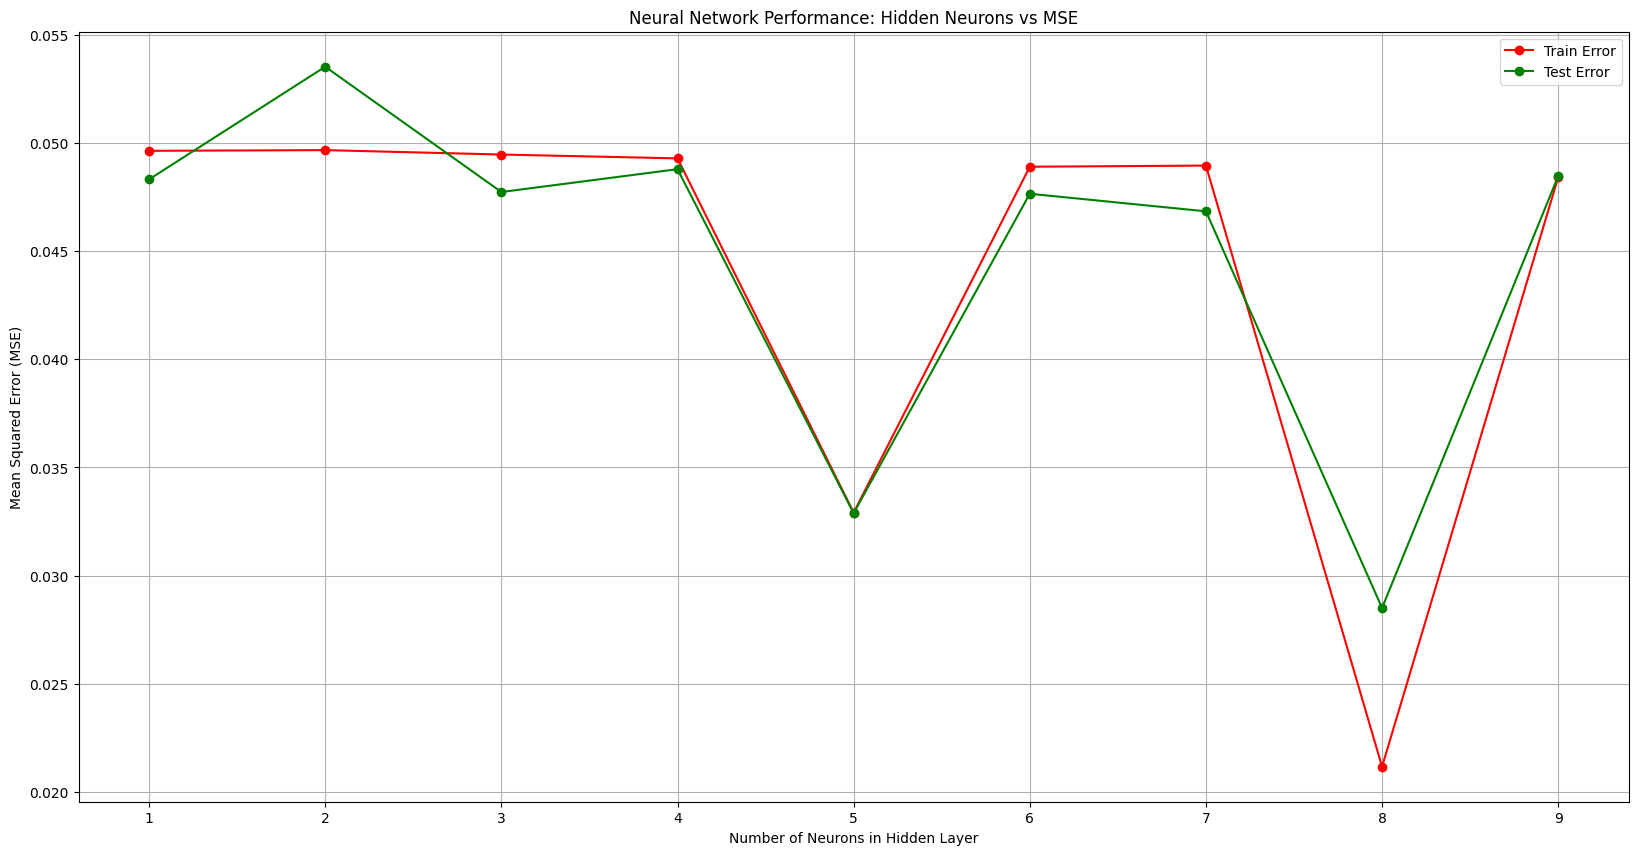

In [10]:
# ---- Visualization ---- #
plt.figure(figsize=(20,10))
plt.plot(range(1, 10), train_errors_list, label='Train Error', marker='o', color='red')
plt.plot(range(1, 10), test_errors_list, label='Test Error', marker='o', color='green')
plt.title('Neural Network Performance: Hidden Neurons vs MSE')
plt.xlabel('Number of Neurons in Hidden Layer')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Report

#### Question 1
If all the weights in a neural network are initialized to zero, the network is said to suffer from symmetry. During the feedforward process, every neuron in the hidden layer will recieve the same input and, since these algorithms are deterministic, produce the same output. As a consequence, during backpropagation, the gradients for all these neurons will be identical.

As a result, the neurons will remain identical througout the entire training process, preventing the network from learning any diverse features. This effectively reduces the effectiveness of the entire network to that of a single neuron. To combat this we initialize with random synapse weights.

#### Question 2
* An epoch is used to describe one pass of the complete dataset through the neuron network.
* A batch is the subset of the training dataset used to update weights in a single step. Instead of using the entire dataset at once, it may be broken up into multiple batches.
* An iteration is the number of batches processed to complete a single epoch.

#### Question 3
* Batch Gradient Descent calculates the error for the entire training dataset before updating the weights.It is computationally slower, evident especially in larger datasets. This allows for smooth convergence.
* Stochastic Gradient Descent updates weights after each individual training example. This makes training faster but convergence noisier.

#### Question 4
If initialization must be stochastic to prevent symmetry, if done improperly (using very small or very large numbers), it can result in vanishing or exploding gradients, causing very slow learning rates or causing the model's loss function to overflow respectively.

#### Question 5
Hyperparameters in a multi-layer neural network.

1) Learning rate $\alpha$
2) Number of hidden layers
3) Number of neurons
4) Number of epochs
5) Error tolerance (for convergence checking)
6) Loss function (Eg. MSE -- Mean Squared Error)
7) Weight init. method (Eg. Stochastic Initialization)
8) Activation Function
9) Batch Size
10) Optimizer
